In [1]:
# Imports for Regression
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import LabelEncoder


In [2]:
# Load the cleaned dataset
ev_data = pd.read_csv('Electric_Vehicle_Population_Cleaned_Data.csv')

ev_data_filtered = ev_data[(ev_data['Base MSRP'] > 0) & 
                            ~((ev_data['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)') & 
                               (ev_data['Base MSRP'] > 110950))]

le = LabelEncoder()

ev_data_filtered.shape

(3304, 19)

In [3]:
# Encode 'Electric Vehicle Type' for interaction term
ev_data_filtered['Vehicle Type Encoded'] = le.fit_transform(ev_data_filtered['Electric Vehicle Type'])

C:\Users\sakib\AppData\Local\Temp\ipykernel_20104\2303147593.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ev_data_filtered['Vehicle Type Encoded'] = le.fit_transform(ev_data_filtered['Electric Vehicle Type'])


In [4]:

# Feature engineering for regression model
ev_data_filtered['Log_Base_MSRP'] = np.log2(ev_data_filtered['Base MSRP'])
ev_data_filtered['Range_MSRP_Interaction'] = ev_data_filtered['Electric Range'] * ev_data_filtered['Base MSRP']
ev_data_filtered['Range_Type_Interaction'] = ev_data_filtered['Electric Range'] * ev_data_filtered['Vehicle Type Encoded']

C:\Users\sakib\AppData\Local\Temp\ipykernel_20104\1117976173.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ev_data_filtered['Log_Base_MSRP'] = np.log2(ev_data_filtered['Base MSRP'])
C:\Users\sakib\AppData\Local\Temp\ipykernel_20104\1117976173.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ev_data_filtered['Range_MSRP_Interaction'] = ev_data_filtered['Electric Range'] * ev_data_filtered['Base MSRP']
C:\Users\sakib\AppData\Local\Temp\ipykernel_20104\1117976173.py:4: SettingWithCopyWarning: 
A value

In [5]:
# For regression, choose relevant features
X_reg = ev_data_filtered[['Electric Range', 'Model Year', 'Clean Alternative Fuel Vehicle (CAFV) Eligibility', 'Electric Utility', 'Postal Code', 'County']]
y_reg = ev_data_filtered['Base MSRP']


In [6]:

# Encode categorical variables for regression
X_reg['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] = le.fit_transform(X_reg['Clean Alternative Fuel Vehicle (CAFV) Eligibility'])
X_reg['Electric Utility'] = le.fit_transform(X_reg['Electric Utility'])
X_reg['Postal Code'] = le.fit_transform(X_reg['Postal Code'])
X_reg['County'] = le.fit_transform(X_reg['County'])

C:\Users\sakib\AppData\Local\Temp\ipykernel_20104\1808013879.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_reg['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] = le.fit_transform(X_reg['Clean Alternative Fuel Vehicle (CAFV) Eligibility'])
C:\Users\sakib\AppData\Local\Temp\ipykernel_20104\1808013879.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_reg['Electric Utility'] = le.fit_transform(X_reg['Electric Utility'])
C:\Users\sakib\AppData\Local\Temp\ipykernel_20104\1808013879.py:4: SettingWi

In [7]:
# Step 1: Split data into training and testing sets for regression (80% training, 20% testing)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [8]:
# Step 2: Polynomial Regression Model
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_reg)  # Fit and transform on the training set
X_test_poly = poly.transform(X_test_reg)  # Only transform the test set



# Fit the Polynomial regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_reg)  # Fit the model
y_pred_poly = poly_model.predict(X_test_poly)  # Make predictions



# Polynomial Regression Evaluation
mse_poly = mean_squared_error(y_test_reg, y_pred_poly)
r2_poly = r2_score(y_test_reg, y_pred_poly)

print(f"Polynomial Regression MSE: {mse_poly:.2f}")
print(f"Polynomial Regression R²: {r2_poly:.2f}")

Polynomial Regression MSE: 114694722.54
Polynomial Regression R²: 0.63


In [9]:

# Step 3: Random Forest Regression Model
rf = RandomForestRegressor(random_state=42,max_depth=3)
rf.fit(X_train_reg, y_train_reg)  # Fit Random Forest on the original training data (not polynomial)
y_pred_rf = rf.predict(X_test_reg)  # Make predictions with Random Forest

# Random Forest Evaluation
mse_rf = mean_squared_error(y_test_reg, y_pred_rf)
r2_rf = r2_score(y_test_reg, y_pred_rf)

print(f"Random Forest Regression MSE: {mse_rf:.2f}")
print(f"Random Forest Regression R²: {r2_rf:.2f}")

Random Forest Regression MSE: 47932214.52
Random Forest Regression R²: 0.85


In [10]:
# Step 4: Cross-validation for Random Forest and Polynomial Regression
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Cross-validation for Random Forest
cv_scores_rf = cross_val_score(rf, X_reg, y_reg, cv=kfold, scoring='neg_mean_squared_error')
cv_mse_rf = -np.mean(cv_scores_rf)
cv_r2_rf = np.mean(cross_val_score(rf, X_reg, y_reg, cv=kfold, scoring='r2'))

# Cross-validation for Polynomial Regression
cv_scores_poly = cross_val_score(poly_model, poly.fit_transform(X_reg), y_reg, cv=kfold, scoring='neg_mean_squared_error')
cv_mse_poly = -np.mean(cv_scores_poly)
cv_r2_poly = np.mean(cross_val_score(poly_model, poly.fit_transform(X_reg), y_reg, cv=kfold, scoring='r2'))

print(f"Random Forest Regression Cross-Validation MSE: {cv_mse_rf:.2f}")
print(f"Random Forest Regression Cross-Validation R²: {cv_r2_rf:.2f}")
print(f"Polynomial Regression Cross-Validation MSE: {cv_mse_poly:.2f}")
print(f"Polynomial Regression Cross-Validation R²: {cv_r2_poly:.2f}")


Random Forest Regression Cross-Validation MSE: 36745502.94
Random Forest Regression Cross-Validation R²: 0.87
Polynomial Regression Cross-Validation MSE: 98713168.14
Polynomial Regression Cross-Validation R²: 0.65


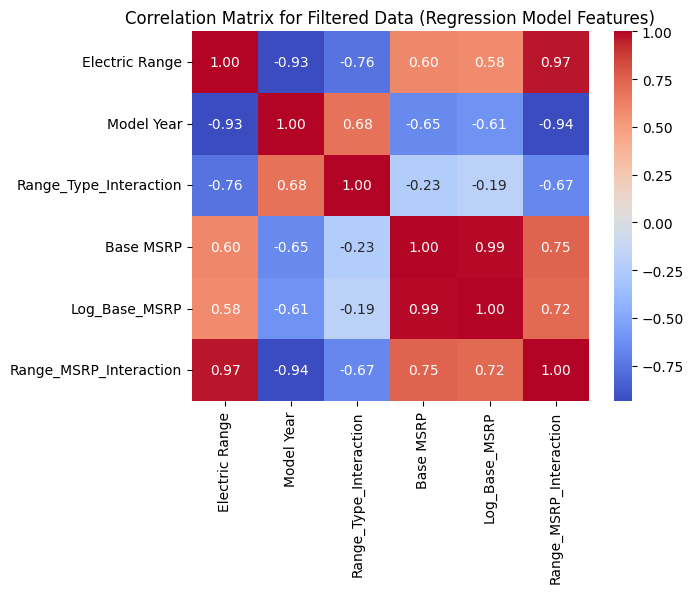

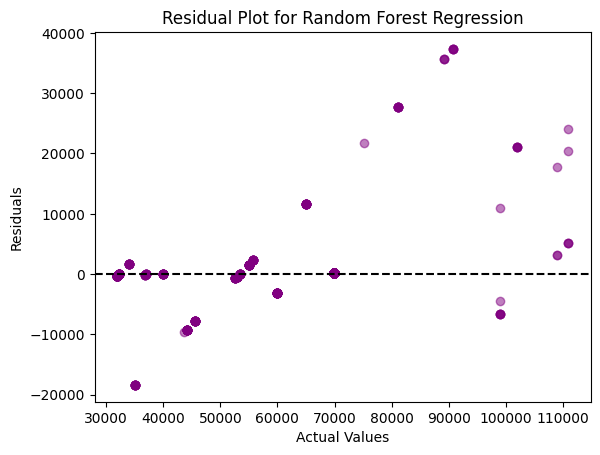

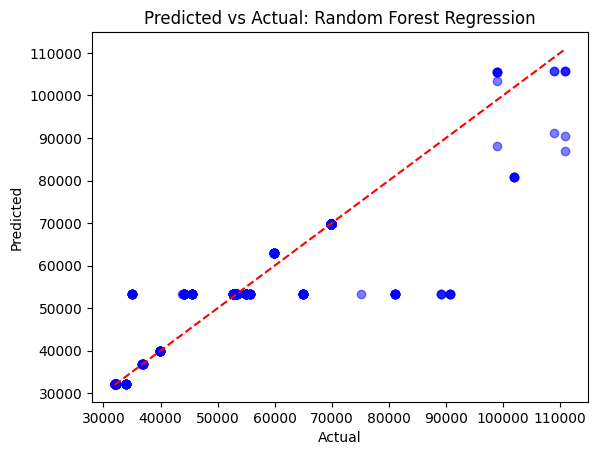

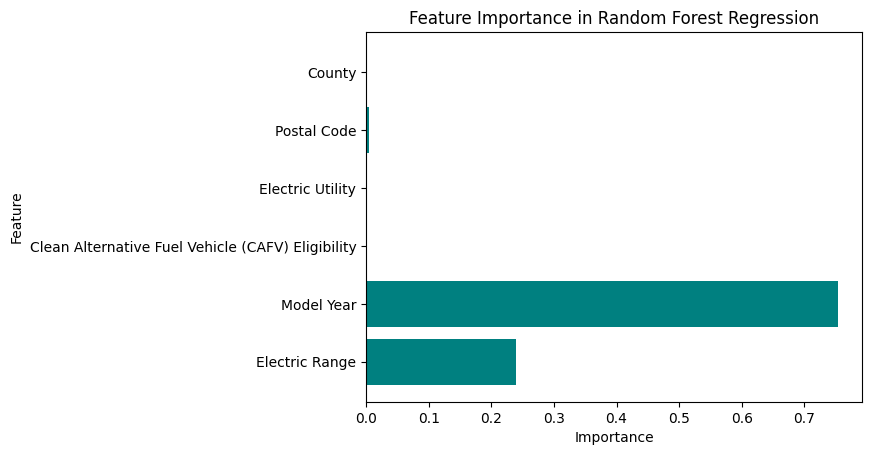

In [11]:


# Step 5: Visualizations for Regression
# Correlation Matrix
corr_matrix_filtered = ev_data_filtered[['Electric Range', 'Model Year', 'Range_Type_Interaction', 'Base MSRP', 'Log_Base_MSRP', 'Range_MSRP_Interaction']].corr()
sns.heatmap(corr_matrix_filtered, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix for Filtered Data (Regression Model Features)")
plt.show()

# Residual Plot for Random Forest Regression
plt.scatter(y_test_reg, y_test_reg - y_pred_rf, alpha=0.5, color="purple")
plt.axhline(y=0, color="black", linestyle="--")
plt.title("Residual Plot for Random Forest Regression")
plt.xlabel("Actual Values")
plt.ylabel("Residuals")
plt.show()

# Predicted vs Actual Plot for Random Forest Regression
plt.scatter(y_test_reg, y_pred_rf, alpha=0.5, color="blue")
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], color="red", linestyle="--")
plt.title("Predicted vs Actual: Random Forest Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

# Feature Importance Plot for Random Forest Regression
feature_importance = rf.feature_importances_
feature_names = X_reg.columns
plt.barh(feature_names, feature_importance, color='teal')
plt.title("Feature Importance in Random Forest Regression")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


Polynomial Regression MSE: 114694722.54
Polynomial Regression R²: 0.63
Random Forest Regression MSE: 47932214.52
Random Forest Regression R²: 0.85


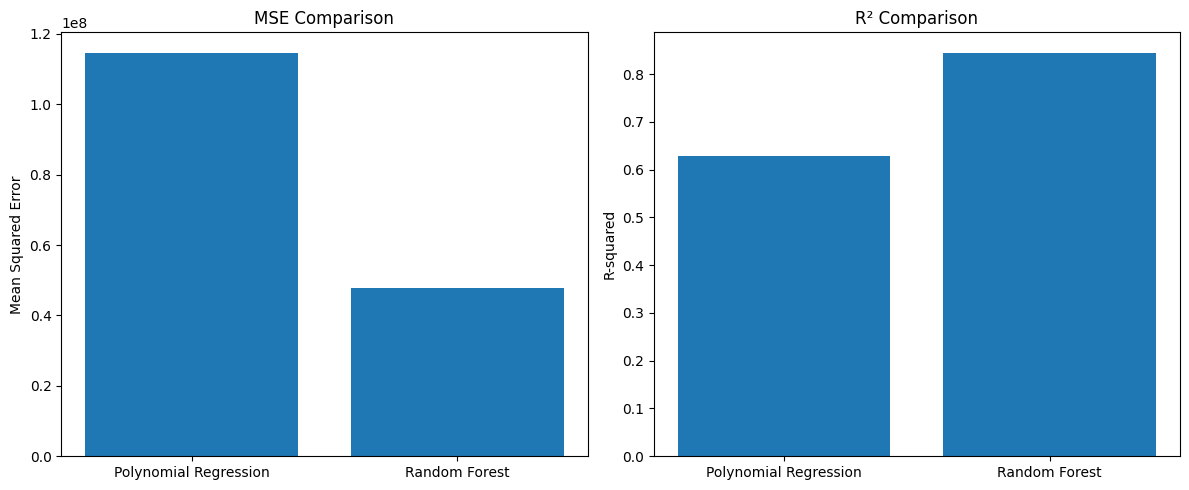

In [12]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Polynomial Regression Results
mse_poly = mean_squared_error(y_test_reg, y_pred_poly)
r2_poly = r2_score(y_test_reg, y_pred_poly)

# Random Forest Regression Results
mse_rf = mean_squared_error(y_test_reg, y_pred_rf)
r2_rf = r2_score(y_test_reg, y_pred_rf)

print(f"Polynomial Regression MSE: {mse_poly:.2f}")
print(f"Polynomial Regression R²: {r2_poly:.2f}")
print(f"Random Forest Regression MSE: {mse_rf:.2f}")
print(f"Random Forest Regression R²: {r2_rf:.2f}")

# Visualize results
models = ['Polynomial Regression', 'Random Forest']
mse_scores = [mse_poly, mse_rf]
r2_scores = [r2_poly, r2_rf]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.bar(models, mse_scores)
ax1.set_ylabel('Mean Squared Error')
ax1.set_title('MSE Comparison')

ax2.bar(models, r2_scores)
ax2.set_ylabel('R-squared')
ax2.set_title('R² Comparison')

plt.tight_layout()
plt.show()